In [2]:
import pandas as pd
import os 
import allel
import random
import subprocess
import pickle
from os import path as op
import numpy as np

import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px



/home/tbellagio/.local/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Here I just test the difference in between weather stations and era 5 land and then save era5 ladn data for the 3 years of experiment 

In [2]:
flowers = pd.read_csv('/home/tbellagio/safedata/meixilin/grenenet/metadata/data/samples_data.csv')

In [3]:
flowers = pd.read_csv('/home/tbellagio/safedata/meixilin/grenenet/metadata/data/merged_samples_data.csv')

In [4]:
flowers['site'] = flowers['sample_name'].str.split('_').str[0]
flowers['gen'] = flowers['sample_name'].str.split('_').str[1]
flowers['plot'] = flowers['sample_name'].str.split('_').str[2]

In [6]:
final_gen = flowers.groupby(['site', 'plot'])['generation'].max().reset_index()

In [7]:
final_gen = flowers.merge(final_gen, on = ['site', 'plot','generation'])

In [8]:
#final_gen.to_csv('final_gen.csv')

In [9]:
#Choose SNPs for GEA structure correction in baypass

<Axes: xlabel='dist2site_km', ylabel='Count'>

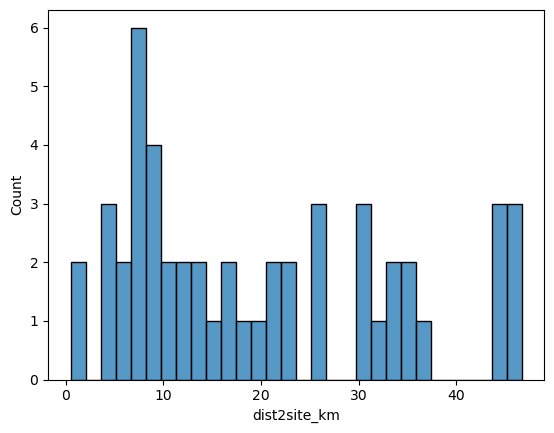

In [10]:
## test weather stations

sites = pd.read_csv('sites.csv')

ws = pd.read_csv('~/grene/data/weatherstation_data.csv')[['site', 'stationid']].drop_duplicates()

ws2 = pd.read_csv('~/grene/data/weatherstation_info.csv')[['stationid', 'dist2site', 'station_longitude', 'station_latitude',]]

distances = ws2.merge(ws).merge(sites) #.to_csv('distances.csv')

distances['dist2site_km'] = distances['dist2site']/1000

sns.histplot(distances['dist2site_km'], bins = 30)

In [ ]:
## create and export cliamtic data during the 3 frist year of experiments 
## clim_sites_during_exp

In [9]:
sites = pd.read_csv( '/home/tbellagio/safedata/meixilin/grenenet/metadata/data/locations_data.csv')

In [10]:
sites = sites[['site','longitude','latitude']]

In [11]:
my_cd = pd.read_csv('climate_data.csv')

In [12]:
my_cd = my_cd.merge(sites)

my_cd['t2m_celcius'] = my_cd['t2m'] - 273.15
my_cd['tp_mm'] = my_cd['tp'] * 1000

In [13]:
## calculate average across the experiment 
my_cd['time'] = pd.to_datetime(my_cd['time'])
## keep onyl the first 3 years
my_cd = my_cd[my_cd['time'].dt.year.isin([2018,2019,2020])]

In [14]:
## for the temperature we want the average 
temp = my_cd.groupby('site')['t2m_celcius'].mean().reset_index()

In [15]:
total_prec = my_cd.groupby('site')['tp_mm'].sum().reset_index()

In [16]:
total_rad = my_cd.groupby('site')['ssrd'].sum().reset_index()

In [17]:
clim_sites_during_exp = temp.merge(total_prec).merge(total_rad)

In [18]:
clim_sites_during_exp

,site,t2m_celcius,tp_mm,ssrd
0,1,10.420198,84.118836,449051260.5
1,2,15.386614,99.127238,557752472.0
2,3,7.861841,110.311237,483778447.5
3,4,16.622688,72.412631,666568070.0
4,5,14.457700,50.476196,611750418.0
5,6,14.715349,88.941183,555314611.0
6,7,9.981755,126.137000,530884935.0
7,9,11.480573,133.917800,503387356.5
8,10,20.534564,92.674107,599329954.5
9,11,13.082092,115.091279,545360178.0


In [19]:
clim_sites_during_exp.to_csv('clim_sites_during_exp.csv')

In [115]:
clim = pd.read_csv('/home/tbellagio/safedata/meixilin/grenenet/metadata/data/worldclim_sitesdata.csv')

In [106]:
my_cd_mean = my_cd.groupby('site')['t2m_celcius'].mean().reset_index()

my_cd_mean.columns = ['site', 'mean_t2m']

import pandas as pd
import matplotlib.pyplot as plt

# Example data setup
# clim = pd.DataFrame({'site': ['A', 'B'], 'annual_mean_temp': [15, 20]})
# my_cd = pd.DataFrame({'site': ['A', 'A', 'B', 'B'], 'temp': [14, 16, 19, 21], 'time': ['2020-01', '2020-02', '2020-01', '2020-02']})

# Convert time to datetime
my_cd['time'] = pd.to_datetime(my_cd['time'])

# Merge the DataFrames
merged_df = pd.merge(my_cd[['site', 't2m_celcius', 'time']], clim[['site', 'bio1']], on='site').merge(my_cd_mean, on ='site')

In [93]:
px.colors.qualitative.Alphabet

<module '_plotly_utils.colors.qualitative' from '/home/tbellagio/mambaforge/envs/pipeline_snakemake/lib/python3.9/site-packages/_plotly_utils/colors/qualitative.py'>

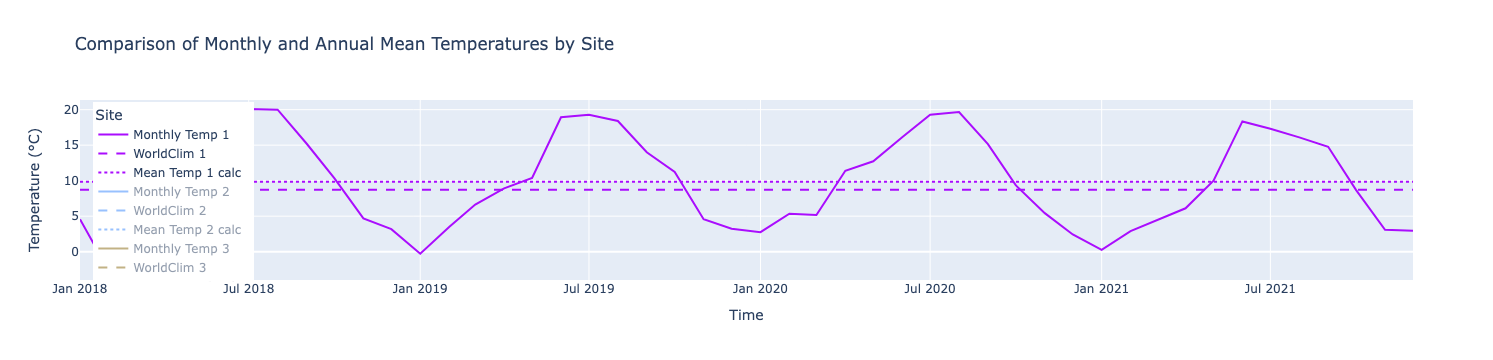

In [114]:
# Create a figure object
fig = go.Figure()

# Define a color palette
colors = px.colors.qualitative.Alphabet[:len(merged_df['site'].unique())]  # Adjust as per the number of sites

# Loop through each site and plot both the monthly temperatures and the annual mean temperatures
for (site, group), color in zip(merged_df.groupby('site'), colors):
    # Add the monthly temperature line
    fig.add_trace(go.Scatter(x=group['time'], y=group['t2m_celcius'],
                             mode='lines', name=f'Monthly Temp {site}',
                             line=dict(color=color)))

    # Add the annual mean temperature horizontal line
    fig.add_trace(go.Scatter(x=[group['time'].min(), group['time'].max()], 
                             y=[group['bio1'].values[0], group['bio1'].values[0]],
                             mode='lines', name=f'WorldClim {site}',
                             line=dict(color=color, dash='dash')))
    # Add the calculated annual mean temperature horizontal line
    fig.add_trace(go.Scatter(x=[group['time'].min(), group['time'].max()], 
                             y=[group['mean_t2m'].values[0], group['mean_t2m'].values[0]],
                             mode='lines', name=f'Mean Temp {site} calc',
                             line=dict(color=color, dash='dot')))

# Update layout
fig.update_layout(
    title='Comparison of Monthly and Annual Mean Temperatures by Site',
    xaxis_title='Time',
    yaxis_title='Temperature (°C)',
    legend_title='Site',
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)

# Show plot
fig.show()

In [85]:
comparison = pd.DataFrame({'site': merged_df['site'].unique()})

comparison = comparison.merge(merged_df.groupby('site')['bio1'].mean().reset_index())

comparison = comparison.merge(merged_df.groupby('site')['t2m_celcius'].mean().reset_index(), on = 'site')

comparison['site_str'] = comparison['site'].astype(str)

import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'comparison' is your DataFrame containing 'bio1' and 't2m_celcius' columns
sns.scatterplot(data=comparison, x='bio1', y='t2m_celcius')

# Get current axis
ax = plt.gca()

# Find limits for x and y axis
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),  # min of the lower bounds
    max(ax.get_xlim()[1], ax.get_ylim()[1])   # max of the upper bounds
]

# Now plot the diagonal line from (xmin, ymin) to (xmax, ymax)
ax.plot(lims, lims, 'k-', alpha=0.75, zorder=0, linestyle="--")  # 'k-' means black line, '--' dashed line
ax.set_aspect('equal')  # This ensures the aspect ratio is equal, making the 1:1 line actually diagonal
ax.set_xlim(lims)  # Set limits back to the max and min found
ax.set_ylim(lims)

plt.show()


In [129]:
#pd.read_csv('/home/tbellagio/safedata/ath_evo/grenephase1-data/merged_tables/merged_hapFIRE_allele_frequency_LDpruned.txt', sep = '\t')

In [13]:
#all_samples_af = os.listdir('/carnegie/nobackup/scratch/xwu/grenet/hapFIRE_frequencies/samples/snp_frequency/')

In [22]:
## the size of this file is 3235481 * 745  
path_all_af = '/carnegie/nobackup/scratch/xwu/grenet/merged_frequency/merged_hapFIRE_allele_frequency.csv'

In [23]:
## path to ld prunned allele freq
path_ldp_af = '/carnegie/nobackup/scratch/xwu/grenet/merged_frequency/merged_hapFIRE_allele_frequency_LDpruned.txt'

In [36]:
samples = pd.read_csv(path_ldp_af, sep = '\t',nrows=1).columns

## for now lets just work with final generation
samples = [value for value in samples if value in final_gen['sample_name'].tolist()]

In [37]:
# Read the file with only the specified columns
df_ldp = dd.read_csv(path_ldp_af, sep = '\t', usecols=samples)

In [38]:
df_shape = df_ldp.shape

In [39]:
# The number of rows needs to be computed; the number of columns is immediate
num_rows = df_shape[0].compute()  # This computes the actual number of rows
num_columns = df_shape[1] 

In [40]:
num_rows

13985

In [41]:
num_columns

60

In [35]:
## get the vcf file frothe chromosomes and positions 

## ld pruned vcf file
ld_prunned_vcf_file = '/carnegie/nobackup/scratch/xwu/grenet/hapFIRE_updatedVCF/greneNet_final_v1.1_LDpruned.recode.vcf'
ld_prunned_vcf = allel.read_vcf(ld_prunned_vcf_file)